# Imports

In [1]:
# Imports
import os
import sys
import gc
sys.path.append('../src/utils')
sys.path.append('../src')
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm
import h5py
import joblib
import torch
import fvdb.nn as fvnn
import mesh_tools as mt
from models import unet as unetModels
import matplotlib.pyplot as plt

import igl
import fvdb
from meshplot import plot

# Utils

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def vdb_marching_cubes(out: fvnn.VDBTensor):
    '''computes marching cubes for a VDBTensor'''
    nv, nf, _ = out.grid.marching_cubes(out.data)
    return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()

def plot_vdb(out: fvnn.VDBTensor):
    '''plots a VDBTensor using mesh_tools'''
    nv, nf = vdb_marching_cubes(out)
    plot(nv, nf)

def fetch_numpy_values(grid: fvdb.GridBatch, arr: np.array, size:int):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    # ijk = grid.ijk.jdata.cpu().detach().numpy()+(size-1)//2
    ijk = grid.ijk.jdata.cpu().detach().numpy()
    if max(ijk[:, 0]) >= arr.shape[0] or max(ijk[:, 1]) >= arr.shape[1] or max(ijk[:, 2]) >= arr.shape[2]:
        # If indices are out of bounds, we can add the maximum value to the indices
        ijk = np.clip(ijk, 0, np.array(arr.shape) - 1)
        # print(f"Indices out of bounds. Clipping to max shape: {arr.shape}")
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    return torch.tensor(values, dtype=torch.float32, device=grid.device)

def scaled_sdf(sdf_arr: np.array, sdf_scaling_value: int):
    '''scales the SDF array by the threshold value'''
    return (sdf_scaling_value-1)*sdf_arr[:, None]

def sdf_to_vdb(sdf_arr: np.array, 
                mask: np.array, 
                size=33):

    '''Converts a SDF array to a VDBTensor with a given size and mask.'''
    sdf_scaling_value = (size-1)*2 + 1

    #  create a grid of the size without nomalize actual shape
    ijk_mesh_grid = mt.mesh_grid(size)
    ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
    
    ijk = torch.tensor(ijk_mesh_grid[mask], 
                        dtype=torch.int, 
                        device=device)
    grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), 
                                    voxel_sizes=(1/(size-1)), 
                                    origins=torch.tensor([0, 0, 0], 
                                    device=device))
    
    sdf_values = fetch_numpy_values(grid, sdf_arr, size)
    sdf_values = scaled_sdf(sdf_values, sdf_scaling_value)
    return fvnn.VDBTensor(grid, grid.jagged_like(sdf_values))

def sdf_from_mesh(mesh_path: str, grid_n: int):
    '''Generates SDF from a mesh file using igl signed distance.'''
    v, f = igl.read_triangle_mesh(mesh_path)
    v = 2*mt.NDCnormalize(v)
    points = mt.mesh_grid(grid_n, True)
    sdf = igl.signed_distance(points, v, f)[0].reshape(grid_n, grid_n, grid_n)/2
    return sdf

def get_all_shifted_positions(vdb_tensor, size, upsample_factor):
        mfg = torch.tensor(mt.mesh_grid(upsample_factor+1), device=vdb_tensor.device) - (upsample_factor//2)
        new_features = []
        for mg in mfg:
            org_ijk = vdb_tensor.grid.ijk.jdata
            ijk = (upsample_factor * org_ijk + mg).view(-1, 3)
            ijk = np.clip(ijk.cpu().detach().numpy(), 0, (size-1)*upsample_factor)
            ijk_vector = ijk - (org_ijk.cpu().detach().numpy() * upsample_factor)
            ijk_vector = ijk_vector / (upsample_factor // 2)  # Normalize to values between -1 and 1
            ijk_vector = torch.tensor(ijk_vector, dtype=torch.float32, device=vdb_tensor.device)
            new_features.append(torch.cat([vdb_tensor.data.jdata, ijk_vector], axis=-1))
        return new_features
    
def prepare_all_inputs(sdf_numpy, grid_size, upsample_factor=4):
    '''prepare voxel 4D input: SDF+displacement'''
    mask_threshold = grid_size*2+1
    mask = mt.make_mask_close(sdf_numpy, mask_threshold)
    input_vdb = sdf_to_vdb(sdf_numpy, mask, grid_size)
    new_features = get_all_shifted_positions(input_vdb, grid_size, upsample_factor)
    all_inputs = []
    for feature in new_features:
        all_inputs.append(fvnn.VDBTensor(input_vdb.grid,
                                        input_vdb.grid.jagged_like(feature)))
    return all_inputs

def get_prediction(all_inputs, grid_size, upsample_factor, model, BATCH_SIZE=20):
    '''compute model prediction and return VDBTensor'''
    pred_list = []
    vector_list = []
    with torch.no_grad():
        for start in tqdm(range(0, len(all_inputs), BATCH_SIZE)):
            # compute predictions for batched displacement
            batch_vdb = fvdb.jcat(all_inputs[start:start+BATCH_SIZE])
            vector_list.append(batch_vdb.jdata[:, 1:4])
            batch_pred = model(batch_vdb.cuda())
            pred_list.append(batch_pred)
            
    pred_list = fvdb.jcat(pred_list)
    vector = torch.cat(vector_list)
    pred_ijk = (pred_list.ijk.jdata)*upsample_factor + (vector*(upsample_factor//2)).long()
    
    # prepare output grid
    output_grid = fvdb.gridbatch_from_ijk(pred_ijk,voxel_sizes=(1/(grid_size-1)/upsample_factor),
            origins=torch.tensor([0, 0, 0]))
    output_vdb = fvnn.VDBTensor(output_grid, output_grid.jagged_like(torch.zeros(output_grid.num_voxels, device=device)))
    target_sdf = torch.zeros_like(output_vdb.jdata)
    target_div = torch.zeros_like(output_vdb.jdata)
    for i in range(pred_list.jidx.max()+1):
        mask = pred_list.jidx==i
        target_mask = output_grid.ijk_to_index(pred_ijk[mask]).jdata
        target_sdf[target_mask] += pred_list.jdata[mask].flatten()
        target_div[target_mask] += 1
    sdf_scaling_value = (grid_size-1)*2+1
    target_sdf /= target_div
    target_sdf *= (1/(sdf_scaling_value-1))
    output_vdb.data.jdata[:] = target_sdf
    return output_vdb

def prepare_output_grid(all_inputs, grid_size, upsample_factor, device):
    source_ijk = torch.cat([e.ijk.jdata.to(device) for e in all_inputs])
    vector = torch.cat([e.jdata[:, 1:4].to(device) for e in all_inputs])
    pred_ijk = source_ijk*upsample_factor + (vector*(upsample_factor//2)).long()
    output_grid = fvdb.gridbatch_from_ijk(pred_ijk,voxel_sizes=(1/(grid_size-1)/upsample_factor),
                origins=torch.tensor([0, 0, 0]))
    output_vdb = fvnn.VDBTensor(output_grid, output_grid.jagged_like(torch.zeros(output_grid.num_voxels, device=device)))
    return output_vdb


def get_prediction_large(all_inputs, grid_size, upsample_factor, model, BATCH_SIZE=20, device=device):
    '''compute model prediction and return VDBTensor'''
    output_vdb = prepare_output_grid(all_inputs, grid_size, upsample_factor, device)
    target_sdf = torch.zeros_like(output_vdb.jdata)
    target_div = torch.zeros_like(output_vdb.jdata)
    with torch.no_grad():
        for start in tqdm(range(0, len(all_inputs), BATCH_SIZE)):
            # compute predictions for batched displacement
            batch_vdb = fvdb.jcat(all_inputs[start:start+BATCH_SIZE])
            batch_pred = model(batch_vdb.cuda())            
            pred_ijk = (batch_pred.ijk.jdata.to(device))*upsample_factor + (batch_vdb.jdata[:, 1:4]*(upsample_factor//2)).long()
            target_mask = output_vdb.grid.ijk_to_index(pred_ijk.to(device)).jdata
            target_sdf[target_mask] += batch_pred.jdata.flatten().to(device)
            target_div[target_mask] += 1
    sdf_scaling_value = (grid_size-1)*2+1
    target_sdf /= target_div
    target_sdf *= (1/(sdf_scaling_value-1))
    output_vdb.data.jdata[:] = target_sdf
    return output_vdb


### Exp

In [3]:
path = '../run/data/model_weights.pth'

model = unetModels.FVDBUNetBase(
                in_channels=4,
                out_channels=1)

# load the trained model
model.load_state_dict(torch.load(path))
model.eval()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

/tmp/ipykernel_396939/1981330226.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


In [8]:
grid_size = 33
upsample_factor = 4

In [ ]:
# np.save('37361.npy', sdf_numpy)

In [9]:
if True:
    name = "motor.obj" #test_418.obj
    gt_dir = '../../data/{}'.format(name)
    gt_dir = '../../data/GT_thingi/64764.obj'
    
    gt_dir = '../../data/37361.stl'
    sdf_numpy = sdf_from_mesh(gt_dir, grid_size)
    # np.save('{}.npy'.format(name.split('.')[0]), sdf_numpy)
else:
    sdf_numpy = np.load('motor_large.npy')

# filename = "398259"
# import h5py
# with h5py.File(f'/home/nmaruani/data/gt_Thingi32_NDC_norm/{filename}.hdf5', 'r') as f:
#     sdf_numpy = f[f'{grid_size-1}_sdf'][:]


In [ ]:
# v, f = igl.read_triangle_mesh(gt_dir)
# v = 2*mt.NDCnormalize(v)
# mt.export_obj(v, f, '37361_gt.obj')

In [11]:
# from scipy.ndimage import zoom
# vm=.4
# plt.imshow(sdf_numpy[:, 32].T, origin='lower', vmin=-vm, vmax=vm, cmap='seismic')
# for i in range(grid_size):
#     slice_data = sdf_numpy[:, -i-1].T
#     # Upsample by factor of (1024/33)
#     upsampled = zoom(slice_data, 15, order=0)  # order=0 for nearest neighbor
#     plt.imsave(f'sdf_slices/{i}.png', upsampled, origin='lower', vmin=-vm, vmax=vm, cmap='seismic')

In [29]:
v, f = mt.marching_cubes(sdf_numpy)
plot(v,f)
mt.export_obj(v, f, '37361_mc.obj')

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0014387…

In [12]:
large=False

if not large:
    all_inputs = prepare_all_inputs(sdf_numpy, grid_size)
    output_vdb = get_prediction(all_inputs, grid_size, upsample_factor, model, BATCH_SIZE=20)
else:
    all_inputs = prepare_all_inputs(sdf_numpy, grid_size)
    all_inputs = [e.cpu() for e in all_inputs]
    torch.cuda.empty_cache()
    output_vdb = get_prediction_large(all_inputs, grid_size, upsample_factor, model, BATCH_SIZE=1, device='cpu')
    output_vdb.jdata.sum()

100%|██████████| 7/7 [00:00<00:00,  8.24it/s]


In [13]:
# name = "motor"
# mt.export_obj(*vdb_marching_cubes(-output_vdb), '{}_ours.obj'.format(name.split('.')[0]))

In [9]:
# out_size = 129
# sdf = np.zeros((out_size, out_size, out_size))
# sdf[*output_vdb.ijk.jdata.T.cpu().detach().numpy()] = output_vdb.jdata.flatten().cpu().detach().numpy()
# vm=.01
# plt.imshow(sdf[64].T, vmin=-vm, vmax=vm, cmap='seismic', origin='lower')

# plt.imshow(sdf[64, 20:40, 80:100].T, vmin=-vm, vmax=vm, cmap='seismic', origin='lower')


In [30]:
plot_vdb(output_vdb)


mt.export_obj(*vdb_marching_cubes(-output_vdb), '37361ours.obj')

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5003682…

### LION

In [5]:

grid_size = 33
upsample_factor = 4
filename = "92880"
import h5py
with h5py.File(f'/home/nmaruani/data/gt_Thingi32_NDC_norm/{filename}.hdf5', 'r') as f:
    sdf_numpy = f[f'{grid_size-1}_sdf'][:]


In [ ]:
for  OFF in (np.linspace(0, 0.1, 20)):
    all_inputs = prepare_all_inputs(sdf_numpy-OFF, grid_size)
    
    # output_vdb = get_prediction(all_inputs, grid_size, upsample_factor, model, BATCH_SIZE=20)
    # v, f = vdb_marching_cubes(-output_vdb)
    # mt.export_obj(2*v-1, f, 'lion_offset2/92880_{:.3f}.obj'.format(OFF))
    # inp = all_inputs[0] #MULTIPLY MAX_THRESHOLD BY 3/5
    # inp.data.jdata = inp.jdata[:, 0]
    # v, f = vdb_marching_cubes(-inp)
    # mt.export_obj(2*v-1, f, 'lion_offset_mc/92880_{:.3f}_mc.obj'.format(OFF))


### Dual Contouring

In [15]:
import torch.nn as nn

class GradientFeatures(nn.Module):
    def __init__(self, kernel_size=3, stride=1):
        super(GradientFeatures, self).__init__()
        assert kernel_size==3 or kernel_size==5
        assert stride==1
        
        if kernel_size==3:
            s = torch.tensor([1, 2, 1], dtype=torch.float32)
            d = torch.tensor([-1, 0, 1], dtype=torch.float32)
        elif kernel_size==5:
            s = torch.tensor([1, 1, 1, 1, 1])
            d = torch.tensor([-1, -1, 0, 1, 1]) 
        kx = (s[:, None, None] * s[None, :, None] * d[None, None, :]).unsqueeze(0)
        print(kx.abs().sum())
        ky = (s[:, None, None] * d[None, :, None] * s[None, None, :]).unsqueeze(0)
        kz = (d[:, None, None] * s[None, :, None] * s[None, None, :]).unsqueeze(0)
        grad_xyz = torch.cat((kx,ky,kz))
        # kx
        grad_conv = fvnn.SparseConv3d(1, 3, kernel_size=kernel_size, stride=1, bias=False)
        grad_conv.requires_grad_(False)
        grad_conv.weight*=0
        for i in range(1):
            grad_conv.weight[3*i:3*i+3, i] = grad_xyz/kx.abs().sum()
        self.grad_conv = grad_conv
                
    def forward(self, input):
        return self.grad_conv(input)
    
g_feat = GradientFeatures(kernel_size=3).to('cuda')

tensor(32.)


In [16]:
upfeat = output_vdb.to('cuda')
upfeat.data.jdata = upfeat.data.jdata.view(-1, 1).float()
gradient = g_feat(upfeat)

out_size = 129
raw_grad_array = np.zeros((out_size, out_size, out_size,3))
raw_grad_array[*upfeat.ijk.jdata.T.cpu().detach().numpy()] = ((gradient.jdata).cpu().detach().numpy()*257)
grad_array = (raw_grad_array/2.+.5).clip(0, 1)

In [17]:
output_mask = np.zeros((out_size, out_size, out_size)) 
output_mask[*output_vdb.ijk.jdata.T.cpu().detach().numpy()] = 1

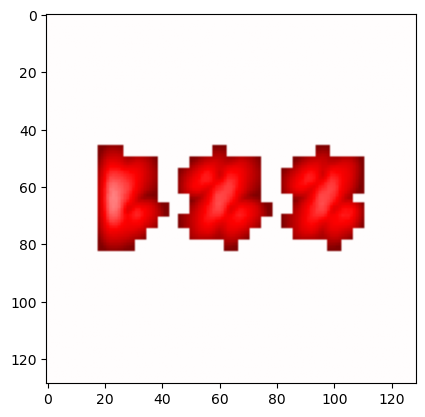

In [18]:
output_sdf = np.zeros((out_size, out_size, out_size))
output_sdf[*output_vdb.ijk.jdata.T.cpu().detach().numpy()] = output_vdb.jdata.flatten().cpu().detach().numpy()
plt.imshow(output_sdf[100], vmin=-0.05, vmax=0.05, cmap='seismic')
plt.imsave('screw_sdf.png', output_sdf[100], vmin=-0.05, vmax=0.05, cmap='seismic')

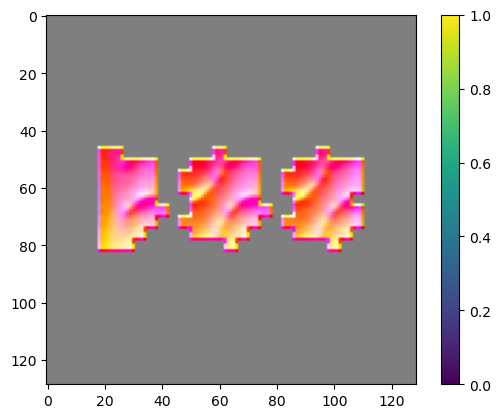

In [19]:
plt.imshow(grad_array[100])
plt.colorbar()
plt.imsave('screw_grad.png', grad_array[100])

In [30]:
## Dual contouring isoext

In [20]:
import isoext
from isoext.sdf import *


grid = isoext.UniformGrid([out_size, out_size, out_size])
grid.set_values(torch.tensor(output_sdf).cuda())
v, f = isoext.marching_cubes(grid)


In [21]:
v, f = isoext.marching_cubes(grid)


In [22]:
mt.export_obj(v.cpu().detach().numpy(), f.cpu().detach().numpy(), 'screw_mc.obj')

In [23]:
plot(v.cpu().detach().numpy(), f.cpu().detach().numpy())

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0007365…

In [24]:
its = isoext.get_intersection(grid)
x = (128*(its.get_points()+1)/2.).cpu().detach().numpy()
g1 = raw_grad_array[*np.floor(x).T.astype(int)]
g2 = raw_grad_array[*np.ceil(x).T.astype(int)]
l = (x - np.floor(x)).max(-1)
fg = l[:, None]*g2 + (1-l)[:, None]*g1
its = isoext.get_intersection(grid)
its.set_normals(torch.tensor(fg).cuda())
v, f = isoext.dual_contouring(grid, its)



In [25]:
mt.export_obj(v.cpu().detach().numpy(), f.cpu().detach().numpy(), 'screw_dc.obj')

In [26]:
plot(v.cpu().detach().numpy(),f.cpu().detach().numpy())


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0005965…